In [7]:
import numpy as np
import xarray as xr
import pickle
from PIL import Image 
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import cv2
from tqdm import tqdm

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [47]:
vid = f'input.avi'
cap = cv2.VideoCapture(vid)
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FS = 2
SECONDS = 10
NFRAMES = FS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
buffer = np.empty((NFRAMES, H, W))

out = cv2.VideoWriter('10s.avi',cv2.VideoWriter_fourcc('M','P','N','G'), 2, (W,H), 0)

for i in tqdm(range(N)):
    _, frame = cap.read()
    buffer[i%NFRAMES] = frame[..., 0]
    if i > NFRAMES:
        out.write(buffer.mean(axis=0).astype(np.uint8))
    
out.release()
cv2.destroyAllWindows()

100%|██████████| 3840/3840 [02:57<00:00, 21.63it/s]


In [178]:
xs.shape

(1600, 500)

In [195]:
np.array(np.meshgrid(np.arange(0, 1600, 100), np.arange(50, 150, 5))).T.reshape(-1, 2)

array([[   0,   50],
       [   0,   55],
       [   0,   60],
       [   0,   65],
       [   0,   70],
       [   0,   75],
       [   0,   80],
       [   0,   85],
       [   0,   90],
       [   0,   95],
       [   0,  100],
       [   0,  105],
       [   0,  110],
       [   0,  115],
       [   0,  120],
       [   0,  125],
       [   0,  130],
       [   0,  135],
       [   0,  140],
       [   0,  145],
       [ 100,   50],
       [ 100,   55],
       [ 100,   60],
       [ 100,   65],
       [ 100,   70],
       [ 100,   75],
       [ 100,   80],
       [ 100,   85],
       [ 100,   90],
       [ 100,   95],
       [ 100,  100],
       [ 100,  105],
       [ 100,  110],
       [ 100,  115],
       [ 100,  120],
       [ 100,  125],
       [ 100,  130],
       [ 100,  135],
       [ 100,  140],
       [ 100,  145],
       [ 200,   50],
       [ 200,   55],
       [ 200,   60],
       [ 200,   65],
       [ 200,   70],
       [ 200,   75],
       [ 200,   80],
       [ 200,

In [ ]:
flow.shape

In [209]:
out = cv2.VideoWriter('10s_flow.avi',cv2.VideoWriter_fourcc('M','J','P','G'), 2, (W,H))
cap = cv2.VideoCapture('10s.avi', 0)
_, prev = cap.read()
hsv = np.zeros_like(prev)
prev = prev[..., 0]

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FS = 2
SECONDS = 10
NFRAMES = FS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))


for frame in tqdm(range(1, 100)):

    _, next = cap.read()
    next = next[..., 0]
    
    flow = cv2.calcOpticalFlowFarneback(prev, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # hsv[..., 0] = ang*180/np.pi/2
    # hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    # bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    # out.write(bgr)
    
    dy = 10
    dx = 10
    y = 0
    x = 1
    # fig, axs = plt.subplots(figsize=(20, 8))
    # q=axs.quiver(ys[::dx, ::dy], 
    #              xs[::dx, ::dy], 
    #              flow[..., y][::dx, ::dy],
    #              flow[..., x][::dx, ::dy],
    #              mag[::dx, ::dy],
    #              scale=400, cmap='jet', norm=plt.Normalize(vmin=0, vmax=40))
    # plt.colorbar(q, ax=axs)
    fig, axs = plt.subplots(figsize=(8, 20))
    s=axs.streamplot(xs[::dy, ::dx], 
                     ys[::dy, ::dx], 
                     flow[..., x][::dy, ::dx],
                     flow[..., y][::dy, ::dx],
                     broken_streamlines=False,
                     integration_direction='forward',
                     start_points=
                     np.concatenate(
                        [np.array(np.meshgrid(np.arange(100, 200, 15), np.arange(0, 1600, 50))).T.reshape(-1, 2),
                         np.array(np.meshgrid(np.arange(200, 300, 20), np.arange(0, 1600, 50))).T.reshape(-1, 2),
                         np.array(np.meshgrid(np.arange(300, 500, 50), np.arange(0, 1600, 50))).T.reshape(-1, 2)]
                     ),
                    #  arrowsize=1,
                    #  density=20,
                     linewidth=mag[::dy, ::dx] / 4,
                     color=mag[::dy, ::dx],
                     cmap='jet', norm=plt.Normalize(vmin=0, vmax=40))
    plt.xlim(0, 500)
    plt.ylim(0, 1600)
    axs.axis('equal') 
    plt.colorbar(s.lines, ax=axs)
    plt.savefig(f'figures/T10s_stream{frame}.jpg')
    plt.close(fig)
out.release()
cv2.destroyAllWindows()

  0%|          | 0/99 [00:00<?, ?it/s]

100%|██████████| 99/99 [10:20<00:00,  6.27s/it]


In [108]:
next.shape

(1600, 500)

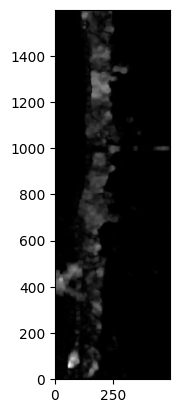

In [104]:
plt.imshow(bgr[..., 0])

In [105]:
mag.shape

(1600, 500)

In [106]:
xs, ys = np.meshgrid(np.arange(500), np.arange(1600))

In [97]:
flow.shape

(1600, 500, 2)

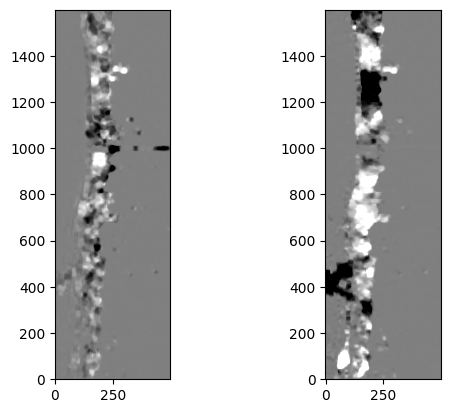

In [109]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(flow[..., 0], vmax=10, vmin=-10) # y
axs[1].imshow(flow[..., 1], vmax=10, vmin=-10) # x


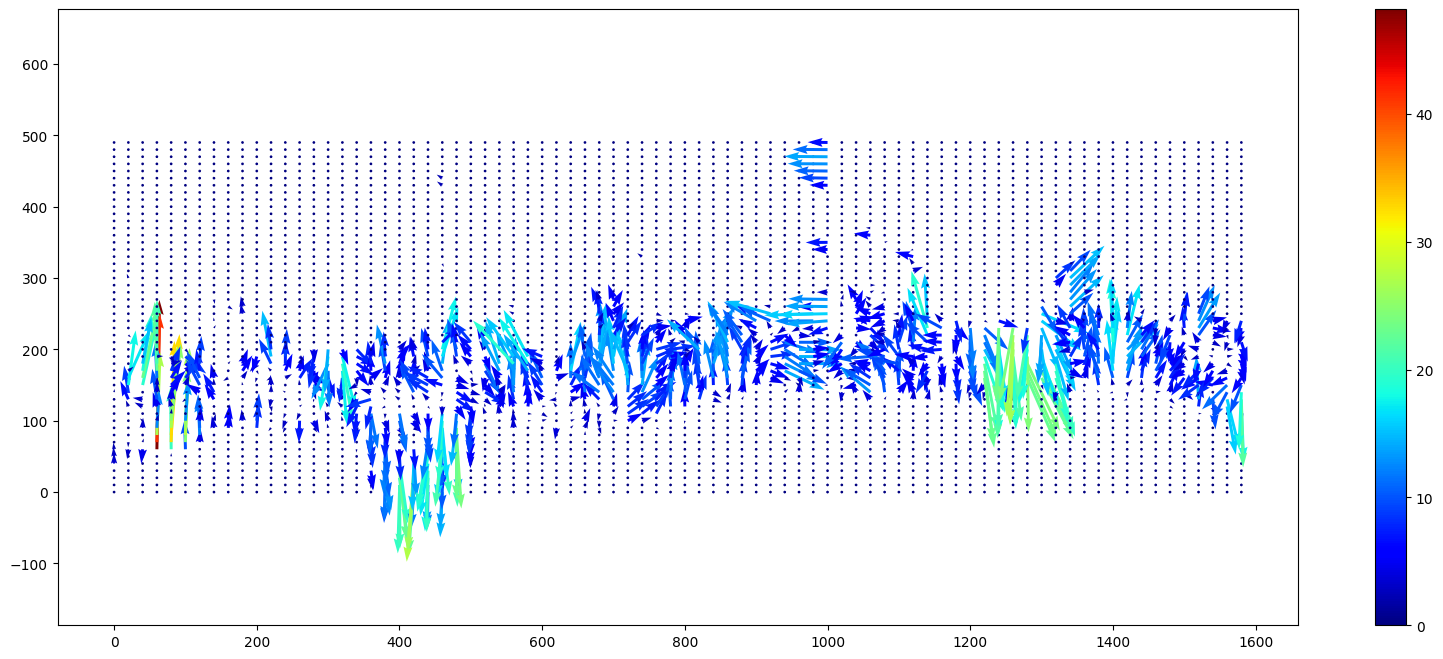

In [144]:

# q=axs.quiver(xs[::dx, ::dy], 
#              ys[::dx, ::dy], 
#              flow[..., 1][::dx, ::dy],
#              flow[..., 0][::dx, ::dy],
#              mag[::dx, ::dy],
#              scale=400, cmap='jet')dx = 20
dy = 10
fig, axs = plt.subplots(figsize=(20, 8))
y = 1
x = 0
q=axs.quiver(ys[::dx, ::dy], 
             xs[::dx, ::dy], 
             flow[..., x][::dx, ::dy],
             flow[..., y][::dx, ::dy],
             mag[::dx, ::dy],
             scale=400, cmap='jet')

axs.axis('equal')
plt.colorbar(q, ax=axs)
plt.savefig(f'figures/10s_flow{i}.jpg')
# qk = axs.quiverkey(q, 0.9, 0.9, 1, r'$2 \frac{m}{s}$', labelpos='E',
#                    coordinates='figure')

